# 01 — Data Exploration

Loads `dataset_<CONFIG>.csv`, visualises each series by block, reports the missing-data pattern, and prints summary statistics.

**Config-aware:** set `CONFIG = "small"` (20 series, identical to the old `dataset_usa.csv` baseline) or `CONFIG = "big"` (50 series) in the setup cell below. Everything downstream is derived from that single switch.

**Prerequisite:** run `python src/data_loader.py --config <CONFIG>` (or `build_dataset(config="<CONFIG>")`) to generate the pre-processed CSV before executing this notebook.

## 0. Environment Setup

**What this cell does:** imports the standard libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and the dataset metadata — `ORDERED_COLS` (ordered list of the 20 series), `BLOCK` (block membership: real / financial / other), `FREQ` (monthly / quarterly) — defined in `src/data_loader.py`. Also defines `block_colors` (colour palette used consistently across all plots in the notebook).

**Why:** the dataset contains 19 monthly series + 1 quarterly series (GDPC1), grouped into three blocks that mirror the factor structure of the model. These dictionaries are used throughout the notebook to colour the plots and aggregate statistics by block.

**What to look for:** no `ImportError` and the printed project root should end in the thesis project directory. If a dependency is missing, run `pip install -r requirements.txt` from the project root.

**Thesis reference:** see Section 2 (The Dynamic Factor Model) — the block distinction reflects the DFM structure where $M = 20$ observable series are loaded on the latent factors $\mathbf{f}_t$ via the loadings matrix $\boldsymbol{\Lambda}$.\


In [1]:
import sys
import os
import pathlib
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG SWITCH ─────────────────────────────────────────────────────────────
# Which dataset configuration to explore:
#   "small" → 20 series  (identical to the old dataset_usa.csv baseline)
#   "big"   → 50 series  (extended configuration)
# Everything downstream (column list, blocks, frequencies, CSV path) is derived
# from this single variable via data_loader.load_config().
CONFIG = "big"     # <-- change to "big" to explore the extended dataset

# ── robust project root detection ─────────────────────────────────────────────
# Works whether Jupyter is launched from the project root or from notebooks/.
def _find_project_root():
    p = pathlib.Path(os.getcwd()).resolve()
    for _ in range(6):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return str(p)
        p = p.parent
    raise RuntimeError(
        "Could not locate project root. "
        "Expected to find both src/ and data/ directories nearby. "
        "Launch Jupyter from the project root or the notebooks/ directory."
    )

project_root = _find_project_root()
src_dir = os.path.join(project_root, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_config

# ── load the chosen config (single source of truth for series/blocks/freq) ────
cfg = load_config(CONFIG)
ORDERED_COLS          = cfg["ORDERED_COLS"]
BLOCK                 = cfg["BLOCK"]
FREQ                  = cfg["FREQ"]
REAL_COLS             = cfg["REAL_COLS"]               # FRED-MD real series only
FINANCIAL_FREDMD_COLS = cfg["FINANCIAL_FREDMD_COLS"]   # FRED-MD financial only
OTHER_COLS            = cfg["OTHER_COLS"]              # FRED-MD other only

# Full block lists (all sources incl. current/spreads), in canonical order, for
# the per-block plots. Real-block GDPC1 is quarterly and is shown separately.
REAL_BLOCK_MONTHLY = [c for c in ORDERED_COLS if BLOCK[c] == "real"      and FREQ[c] == "monthly"]
FINANCIAL_BLOCK    = [c for c in ORDERED_COLS if BLOCK[c] == "financial"]
OTHER_BLOCK        = [c for c in ORDERED_COLS if BLOCK[c] == "other"]

# ── global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"   : 120,
    "font.size"    : 8,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
})
sns.set_theme(style="whitegrid", palette="tab10")

# ── block colour palette — defined here so every subsequent cell can use it ───
block_colors = {"real": "steelblue", "financial": "darkorange", "other": "seagreen"}

print(f"Project root : {project_root}")
print(f"Config       : {CONFIG}  ({len(ORDERED_COLS)} series)")
print("Setup complete.")

Project root : C:\Users\giord\OneDrive\Desktop\Tesi Lorenzo
Config       : big  (50 series)
Setup complete.


## 1. Loading the Dataset

**What this section does:** reads the pre-processed file `data/processed/dataset_<CONFIG>.csv` built by `src/data_loader.py`, containing the USA macroeconomic and financial series from January 1985 to the present, already transformed to stationarity (log-differences, first differences, etc.) following FRED-MD transformation codes. The `small` config has 20 series (== the old `dataset_usa.csv`); the `big` config extends it to 50.

| Source | Update horizon |
|---|---|
| FRED-MD (McCracken & Ng mirror) | Snapshot (~12–18 month lag) |
| FRED direct API (current series, e.g. NFCI) | Real-time |
| FRED direct API — GDPC1 | Quarterly, ~one-quarter lag |

In [2]:
# ── (optional) generate the CSV if it does not exist ──────────────────────────
csv_path = os.path.join(project_root, "data", "processed", f"dataset_{CONFIG}.csv")

if not os.path.exists(csv_path):
    print(f"dataset_{CONFIG}.csv not found — running build_dataset(config='{CONFIG}') ...")
    from data_loader import build_dataset
    FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
    if not FRED_API_KEY:
        raise EnvironmentError(
            "Set the environment variable FRED_API_KEY or replace the empty "
            "string with your key. "
            "Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html"
        )
    df = build_dataset(fred_api_key=FRED_API_KEY, config=CONFIG)
else:
    print(f"Found: {csv_path}")

Found: C:\Users\giord\OneDrive\Desktop\Tesi Lorenzo\data\processed\dataset_big.csv


**Note:** if the CSV already exists the next cell loads it directly. Verify that `shape` reports `497 × 20` and that column `GDPC1` is present.

In [3]:
# ── load the CSV ──────────────────────────────────────────────────────────────
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

print(f"Shape   : {df.shape[0]} months x {df.shape[1]} series")
print(f"From    : {df.index[0].date()}")
print(f"To      : {df.index[-1].date()}")
print(f"Columns : {df.columns.tolist()}")

Shape   : 498 months x 50 series
From    : 1985-01-31
To      : 2026-06-30
Columns : ['INDPRO', 'IPFINAL', 'IPMANSICS', 'PAYEMS', 'MANEMP', 'RPI', 'CMRMTSPLx', 'RETAILx', 'IPCONGD', 'IPDCONGD', 'IPBUSEQ', 'CUMFNS', 'AMDMNOx', 'ANDENOx', 'UNRATE', 'AWHMAN', 'CES0600000007', 'HOUST', 'PERMIT', 'JTSJOL', 'RRSFS', 'S&P 500', 'S&P PE ratio', 'T10YFFM', 'T1YFFM', 'BAAFFM', 'TB3SMFFM', 'TB3MS', 'GS5', 'GS10', 'BAA', 'AAA', 'VIXCLSx', 'GS2', 'ANFCI', 'NFCI', 'term_spread', 'baa_spread', 'aaa_spread', 'CPIAUCSL', 'PCEPI', 'UMCSENTx', 'TWEXAFEGSMTHx', 'WPSFD49207', 'CPILFESL', 'PCEPILFE', 'IR', 'IQ', 'T10YIE', 'GDPC1']


## 1b. NaN Diagnostic Report

**What this cell does:** produces a structured report of the missing-value pattern for every series, decomposing the NaN count into three non-overlapping components:

| Component | Definition |
|---|---|
| **nan\_start** | observations *before* `first_valid_index` (e.g. 1 from $\Delta\ln$, 2 from $\Delta^2\ln$) |
| **nan\_end** | trailing NaN — ragged edge (FRED-MD publication lag) or structural quarterly mask (GDPC1) |
| **nan\_internal** | gaps *in the middle* of the series (0 for monthly; ~328 for GDPC1 by design) |

**Why at this stage:** understanding the missingness structure is essential before any visualisation or estimation step. The pattern determines how the selection matrix $\mathbf{W}_t$ must be constructed in the Kalman filter.

**What to look for:**
- Monthly FRED-MD series: all NaN should be at the *end* (ragged edge), none at start or internally.
- GDPC1: large `nan_internal` (~328) by design (only quarter-end months are observed), plus 2 at start (log-diff) and 2 at end (ragged edge).
- NFCI: zero NaN everywhere (real-time, no publication lag).

**Thesis reference:** see Section 6 (Missing Data and Ragged Edge) and Section 7 (Mariano–Murasawa Approach). The selection matrices $\mathbf{W}_t$ handle ragged edge and quarterly masking in a unified way.\


In [4]:
# ── NaN diagnostic report ─────────────────────────────────────────────────────
from IPython.display import display

nan_report = []
for col in ORDERED_COLS:
    s = df[col]
    total_nan   = int(s.isna().sum())
    first_valid = s.first_valid_index()
    last_valid  = s.last_valid_index()

    if first_valid is None:
        nan_start, nan_end, nan_internal = len(s), 0, 0
    else:
        nan_start    = int(s.loc[:first_valid].isna().sum())
        nan_end      = int(s.loc[last_valid:].isna().sum())
        nan_internal = total_nan - nan_start - nan_end

    nan_report.append({
        "series"      : col,
        "block"       : BLOCK.get(col, "?"),
        "frequency"   : FREQ.get(col, "?"),
        "total_nan"   : total_nan,
        "nan_start"   : nan_start,
        "nan_end"     : nan_end,
        "nan_internal": nan_internal,
        "first_valid" : first_valid.strftime("%Y-%m-%d") if first_valid else None,
        "last_valid"  : last_valid.strftime("%Y-%m-%d")  if last_valid  else None,
    })

nan_report_df = pd.DataFrame(nan_report).set_index("series")
print("NaN Diagnostic Report:\n")
display(nan_report_df)

NaN Diagnostic Report:



,block,frequency,total_nan,nan_start,nan_end,nan_internal,first_valid,last_valid
series,,,,,,,,
INDPRO,real,monthly,3,0,3,0,1985-01-31,2026-03-31
IPFINAL,real,monthly,3,0,3,0,1985-01-31,2026-03-31
IPMANSICS,real,monthly,3,0,3,0,1985-01-31,2026-03-31
PAYEMS,real,monthly,3,0,3,0,1985-01-31,2026-03-31
MANEMP,real,monthly,3,0,3,0,1985-01-31,2026-03-31
RPI,real,monthly,3,0,3,0,1985-01-31,2026-03-31
CMRMTSPLx,real,monthly,4,0,4,0,1985-01-31,2026-02-28
RETAILx,real,monthly,3,0,3,0,1985-01-31,2026-03-31
IPCONGD,real,monthly,3,0,3,0,1985-01-31,2026-03-31


## 2. Time Series Plots by Block

**What this section does:** plots each series on a grid organised by block (real, financial, other), plus GDPC1 separately as a bar chart.

**Why we do it:** visual inspection has two theoretical objectives:
1. **Verify stationarity** — after FRED-MD transformations, series should fluctuate around zero without a visible trend.
2. **Identify heavy tails** — large spikes during recessions (2008–2009, 2020) produce residuals far from the mean; this is exactly the type of variation that motivates the Student-$t$ extension over the Gaussian DFM.

**What to look for:**
- Clear drops in all *real* series during **2008–2009** (Great Recession) and **2020** (COVID-19): these episodes generate observations in the extreme tails of the empirical distribution.
- Spikes in NFCI and credit spreads (BAAFFM, TB3SMFFM) during the same periods: *flight-to-quality* episodes.
- No systematic drift: if a series shows a visible trend, the FRED-MD transformation is insufficient.

**Thesis reference:** see Section 4 (The Student-$t$ Distribution: From Univariate to Multivariate) and Section 5 (Factor Dynamics: VAR(1) with Student-$t$ Shocks). Both components use Student-$t$ innovations to absorb the extreme episodes visible in these plots.\


In [5]:
def plot_block(series_list, block_name, ncols=4, figheight_per_row=2.2):
    """Plot a set of series on an ncols-column grid."""
    n     = len(series_list)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.5, nrows * figheight_per_row),
        sharex=False,
    )
    axes_flat = np.array(axes).flatten()

    for ax, col in zip(axes_flat, series_list):
        s = df[col].dropna()
        ax.plot(s.index, s.values, linewidth=0.9, color="steelblue")
        ax.set_title(col, fontsize=8, fontweight="bold")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=6, rotation=30)
        ax.tick_params(axis="y", labelsize=6)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Block: {block_name}", fontsize=10, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

#### Real Activity Block (8 monthly series from FRED-MD)

Industrial production (`INDPRO`, `IPFINAL`, `IPMANSICS`), employment (`PAYEMS`, `MANEMP`), income (`RPI`), and retail sales (`RETAILx`, `CMRMTSPLx`). These are the main *coincident indicators* of the US business cycle.

Real-activity series (INDPRO, PAYEMS, MANEMP) should display the **2008–2009** (Great Recession) and **2020** (COVID-19) downturns. These outlier periods motivate the Student-$t$ extension of the model (see Section 4 of the thesis: *The Student-$t$ Distribution: From Univariate to Multivariate*). Under a Gaussian DFM, the April 2020 collapse of INDPRO ($-14\%$) would be an event of essentially zero probability; under a Student-$t$ model with low $\nu$, it is improbable but representable.\


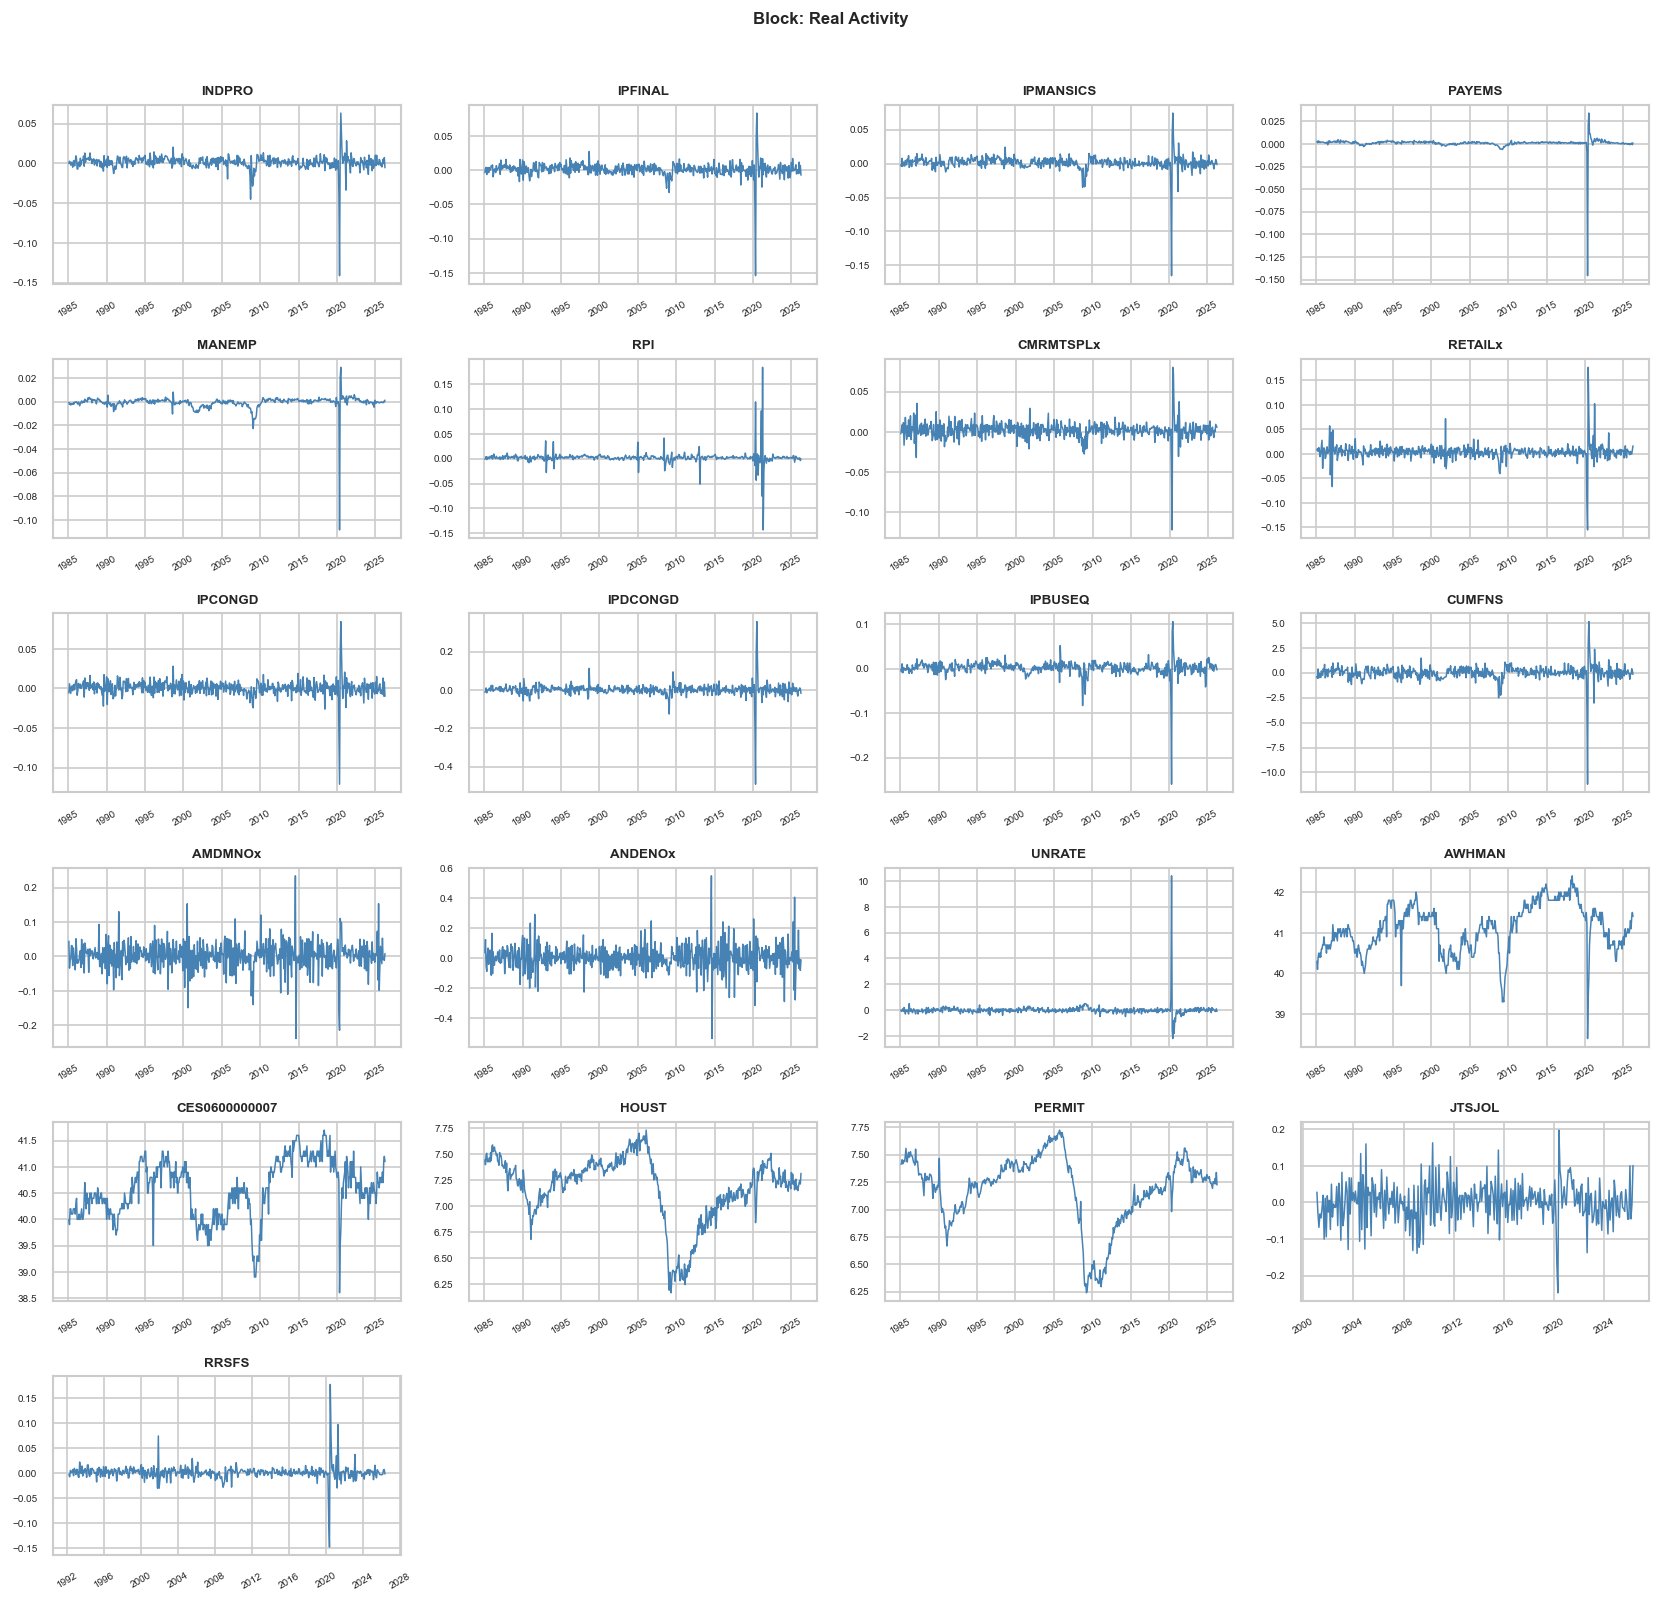

In [6]:
# ── Real block ────────────────────────────────────────────────────────────────
plot_block(REAL_BLOCK_MONTHLY, 'Real Activity')

#### Financial Block (6 FRED-MD series + NFCI)

S&P 500, P/E ratio, bond spreads (BAAFFM), and interest rate differentials (T10YFFM, T1YFFM, TB3SMFFM). Heavy-tailedness is structural in financial series: markets generate shocks with empirical kurtosis well above 3.

**NFCI** should spike during **2008–2009** and **2020**. High values indicate financial stress. NFCI is a composite index of financial conditions constructed by the Chicago Fed, widely used in the Growth-at-Risk literature (Adrian, Boyarchenko, Giannone, 2019). It is the only real-time series in the dataset (zero NaN), making it the most informative in the most recent part of the sample. Its spikes coincide exactly with contractions in real-activity series, confirming the financial-cycle transmission channel.\


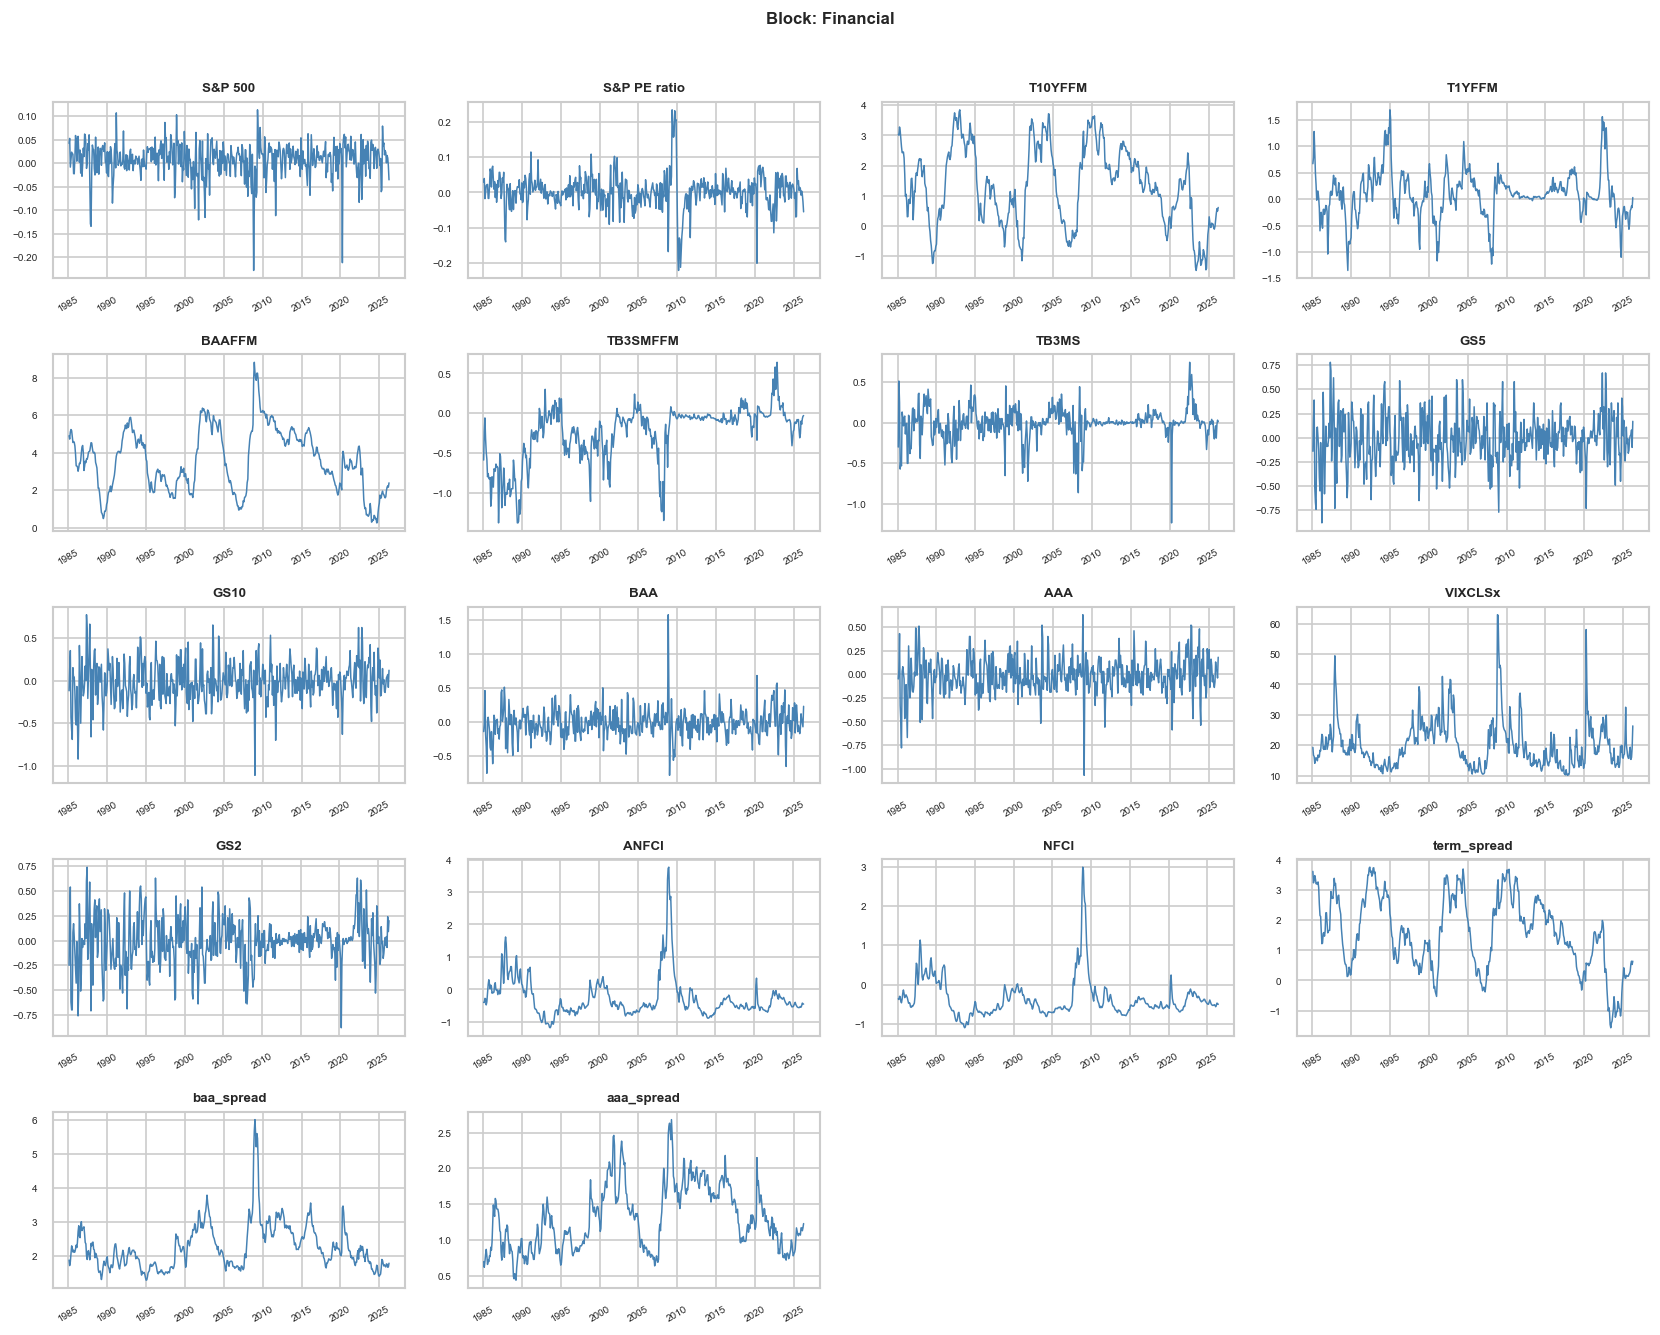

In [7]:
# ── Financial block (FRED-MD + current series + constructed spreads) ─────────
plot_block(FINANCIAL_BLOCK, 'Financial')

#### Other Block — Prices and Sentiment

CPIAUCSL and PCEPI (inflation indices), UMCSENTx (University of Michigan consumer sentiment), TWEXAFEGSMTHx (real effective exchange rate). These series generally have lighter tails than financial series, but post-2020 inflation dynamics and exchange-rate movements produce episodes of intense variation.

Note: CPIAUCSL is transformed by double log-differencing ($\Delta^2 \ln$), consuming two initial observations and accounting for its slightly higher NaN count at the beginning of the sample.\


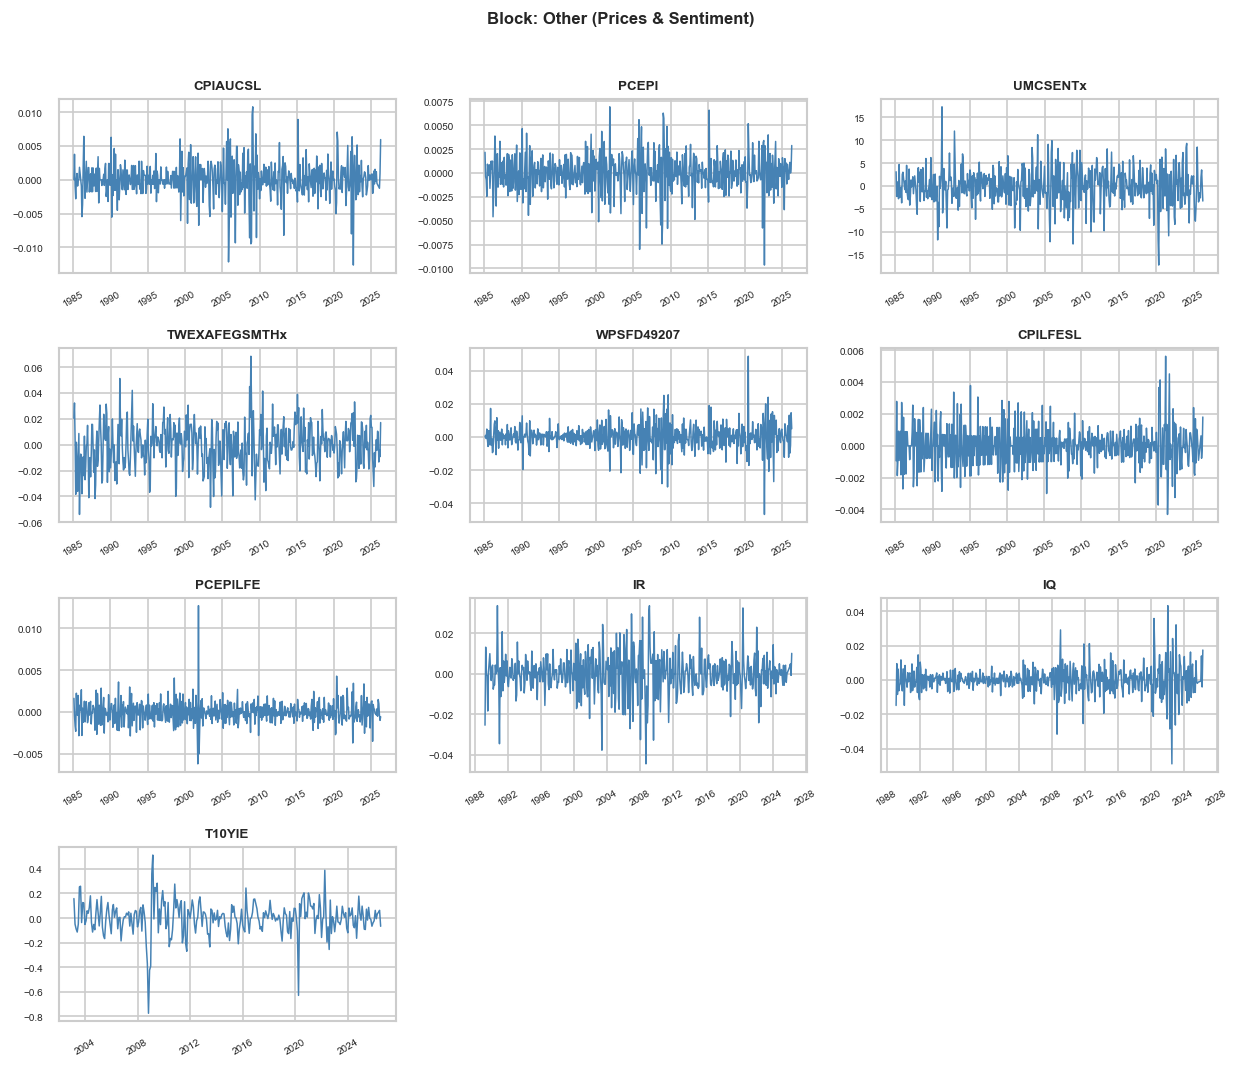

In [8]:
# ── Other block ───────────────────────────────────────────────────────────────
plot_block(OTHER_BLOCK, 'Other (Prices & Sentiment)', ncols=3)

#### GDPC1 — Real US GDP (quarterly, Mariano–Murasawa approach)

GDP is available only once per quarter. In the CSV, GDPC1 is `NaN` for all non-quarter-end months (January, February, April, May, July, August, October, November) — this is not missing data in the traditional sense, but a *mixed-frequency* observation structure handled via the selection matrix $\mathbf{W}_t$.

Bars in **blue** indicate expanding quarters; bars in **red** indicate contractions. The two collapses of 2008–2009 and 2020 are immediately recognisable.

**Thesis reference:** see Section 7 (Mariano–Murasawa Approach). The Mariano–Murasawa (2003) method embeds quarterly GDP into the monthly framework using a constrained measurement equation. The approximation $y_t^{\text{qtr}} \approx \frac{1}{3}(y_t + y_{t-1} + y_{t-2}) + \ldots$ is implemented via $\mathbf{W}_t$.\


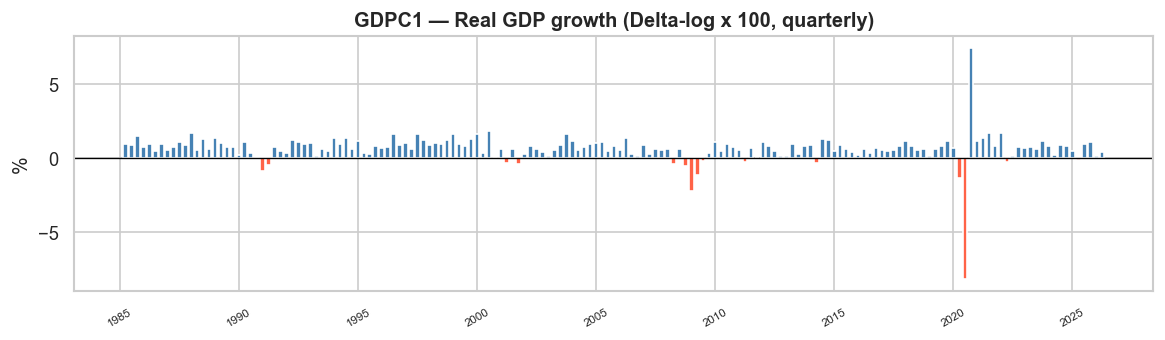

GDP observations available: 165


In [9]:
# ── GDP quarterly bar chart ───────────────────────────────────────────────────
gdp = df["GDPC1"].dropna()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    gdp.index, gdp.values, width=70,
    color=np.where(gdp.values >= 0, "steelblue", "tomato"),
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("GDPC1 — Real GDP growth (Delta-log x 100, quarterly)",
             fontweight="bold")
ax.set_ylabel("%")
ax.tick_params(axis="x", labelsize=7, rotation=30)
plt.tight_layout()
plt.show()
print(f"GDP observations available: {len(gdp)}")

## 3. Missing Data Pattern

**Three structurally distinct types of missingness in the dataset:**

| Type | Series | Cause | Model treatment |
|---|---|---|---|
| **Ragged edge** | 18 FRED-MD series | Snapshot older than current date | $\mathbf{W}_t$ selects observed rows |
| **Quarterly mask** | GDPC1 | Mixed-frequency by design | $\mathbf{W}_t$ + Mariano–Murasawa constraints |
| **Internal NaN** | CPIAUCSL (3 gaps) | Data quality gap in raw FRED-MD | $\mathbf{W}_t$ handles transparently |

**This is not a data quality problem for the model** — it is exactly the use case for which the Kalman filter with selection matrix $\mathbf{W}_t$ was designed. At each period $t$, $\mathbf{W}_t \in \{0,1\}^{n_t \times M}$ selects the $n_t \leq M$ series that are actually observed, reducing the measurement equation to available values only.

**What to look for:**
- The ragged-edge region (right part of the heatmap, **red**) affects nearly all FRED-MD series from the same cut-off date. CMRMTSPLx has a slightly longer ragged edge (3 months instead of 2).
- The structural quarterly mask of GDPC1 (**gold** stripes throughout) is by design.
- **CPIAUCSL** shows 3 **internal NaN** (**purple** marks in the middle of the sample) — a genuine gap in the raw FRED-MD file, not a publication-lag artefact. These reduce its effective sample to 492 observations (vs. 495 for most other series with only a 2-month ragged edge). The $\mathbf{W}_t$ matrix handles these gaps automatically.

**Thesis reference:** see Section 6 (Missing Data and Ragged Edge) and Section 6.1 (Setup: The Selection Matrix $\mathbf{W}_t$), and Section 7 (Mariano–Murasawa Approach). The selection matrices $\mathbf{W}_t$ handle ragged edge, quarterly masking, and internal gaps in a unified way.

---
*In the heatmap: light grey = observed · gold = quarterly mask (GDPC1) · red = ragged edge · purple = internal NaN*

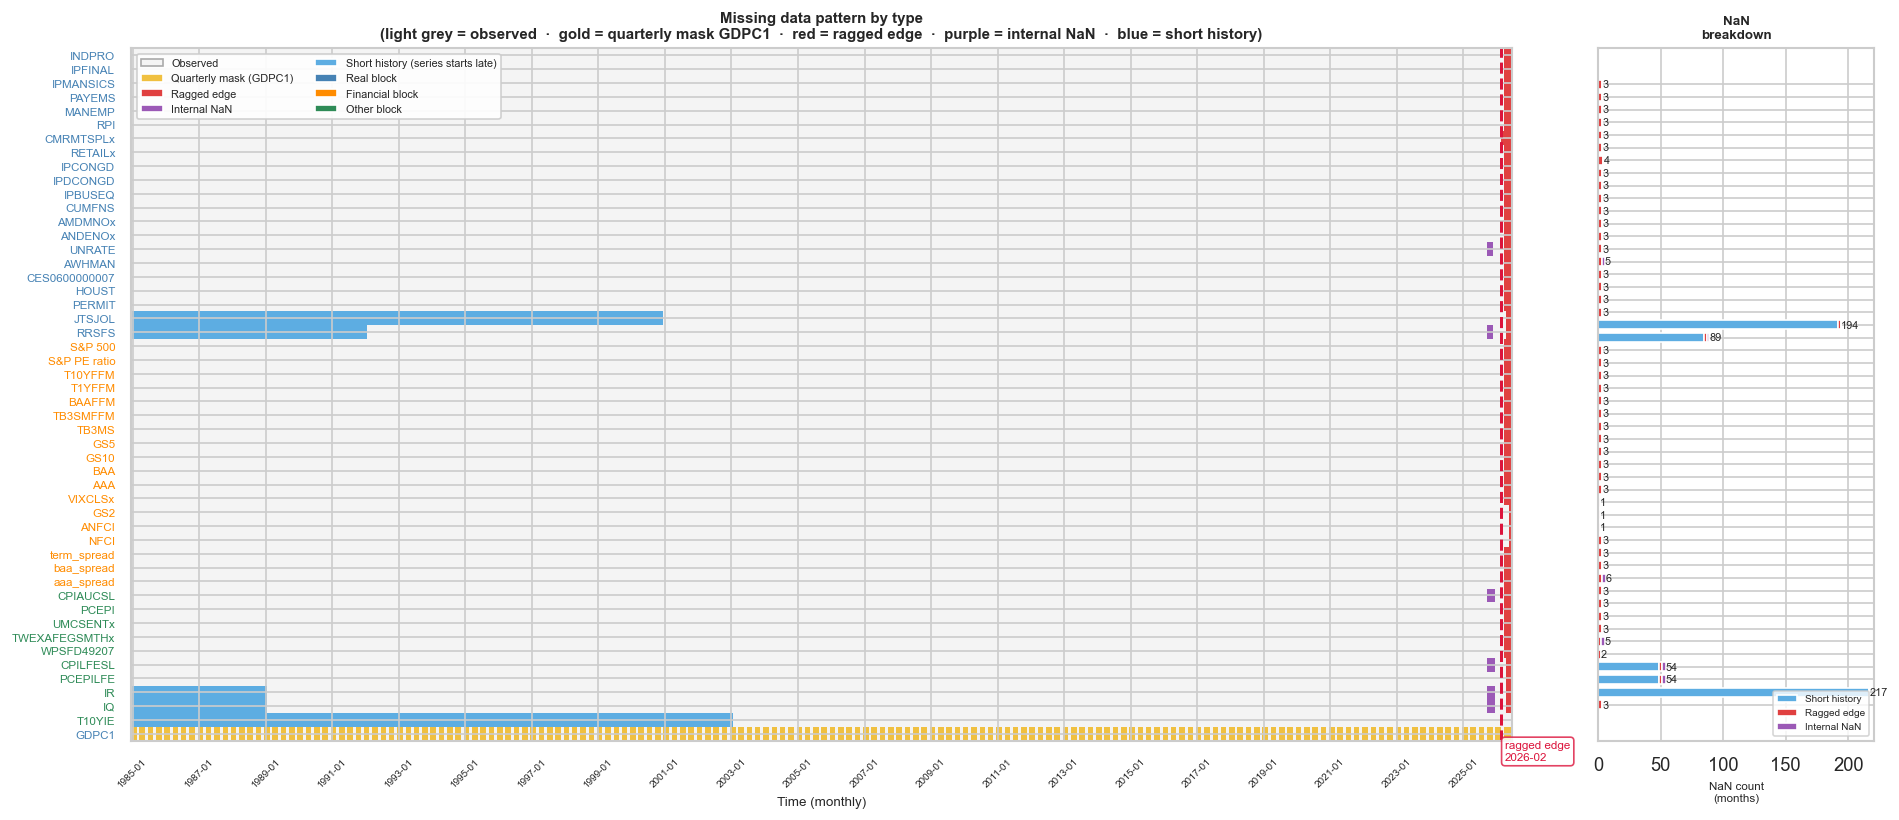

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# 0 = observed   1 = quarterly mask (GDPC1)   2 = ragged edge   3 = internal NaN   4 = short history
pattern = pd.DataFrame(0, index=df.index, columns=ORDERED_COLS)

for col in ORDERED_COLS:
    s = df[col]
    first_valid = s.first_valid_index()
    last_valid  = s.last_valid_index()
    if col == "GDPC1":
        pattern.loc[s.isna(), col] = 1
    else:
        # leading NaN: series starts late (short history)
        if first_valid is not None:
            pattern.loc[s.isna() & (df.index < first_valid), col] = 4
        # ragged edge: after last valid observation
        if last_valid is not None:
            pattern.loc[df.index > last_valid, col] = 2
        # internal NaN: gaps strictly between first and last valid
        if first_valid is not None and last_valid is not None:
            internal_mask = (
                s.isna()
                & (df.index >= first_valid)
                & (df.index <= last_valid)
            )
            pattern.loc[internal_mask, col] = 3

# ── NaN counts for the bar chart ──────────────────────────────────────────────
trailing     = []
internal_nan = []
leading_nan  = []
for col in ORDERED_COLS:
    s  = df[col]
    fv = s.first_valid_index()
    lv = s.last_valid_index()
    trailing.append(0 if lv is None else int(s.loc[lv:].isna().sum()))
    if col == "GDPC1" or fv is None or lv is None:
        internal_nan.append(0)   # GDPC1 internal shown as gold in heatmap
        leading_nan.append(0)
    else:
        mask = s.isna() & (df.index >= fv) & (df.index <= lv)
        internal_nan.append(int(mask.sum()))
        leading_nan.append(int((s.isna() & (df.index < fv)).sum()))

# ── earliest ragged-edge start (first series to go missing) ───────────────────
fredmd_series = [c for c in ORDERED_COLS if c not in ("NFCI", "GDPC1")]
last_valids   = {c: df[c].last_valid_index() for c in fredmd_series}
ragged_start  = min(v for v in last_valids.values() if v is not None)

# ── figure ────────────────────────────────────────────────────────────────────
fig, (ax_map, ax_bar) = plt.subplots(
    1, 2, figsize=(16, 7),
    gridspec_kw={"width_ratios": [5, 1]},
)

# ── heatmap (4-colour) ────────────────────────────────────────────────────────
cmap   = ListedColormap(["#f4f4f4", "#f0c040", "#e04040", "#9b59b6", "#5dade2"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm   = BoundaryNorm(bounds, cmap.N)

ax_map.imshow(
    pattern[ORDERED_COLS].T.values,
    aspect="auto", cmap=cmap, norm=norm, interpolation="none",
)

tick_step = 24
xtick_pos = list(range(0, len(df), tick_step))
ax_map.set_xticks(xtick_pos)
ax_map.set_xticklabels(
    [df.index[i].strftime("%Y-%m") for i in xtick_pos],
    rotation=45, fontsize=6,
)

ax_map.set_yticks(range(len(ORDERED_COLS)))
ax_map.set_yticklabels(ORDERED_COLS, fontsize=7)
for lbl, col in zip(ax_map.get_yticklabels(), ORDERED_COLS):
    lbl.set_color(block_colors.get(BLOCK.get(col, "other"), "black"))

ragged_idx = df.index.get_loc(ragged_start)
label_re   = "ragged edge\n" + ragged_start.strftime("%Y-%m")
ax_map.axvline(ragged_idx + 0.5, color="crimson", linewidth=1.8, linestyle="--")
ax_map.text(
    ragged_idx + 2, len(ORDERED_COLS) - 0.5, label_re,
    fontsize=7, color="crimson", va="top",
    bbox=dict(facecolor="white", edgecolor="crimson",
              boxstyle="round,pad=0.3", alpha=0.8),
)

ax_map.set_title(
    "Missing data pattern by type\n"
    "(light grey = observed  ·  gold = quarterly mask GDPC1  "
    "·  red = ragged edge  ·  purple = internal NaN  ·  blue = short history)",
    fontsize=9, fontweight="bold",
)
ax_map.set_xlabel("Time (monthly)", fontsize=8)

legend_elements = [
    Patch(facecolor="#f4f4f4", edgecolor="#aaa", label="Observed"),
    Patch(facecolor="#f0c040",                   label="Quarterly mask (GDPC1)"),
    Patch(facecolor="#e04040",                   label="Ragged edge"),
    Patch(facecolor="#9b59b6",                   label="Internal NaN"),
    Patch(facecolor="#5dade2",                   label="Short history (series starts late)"),
] + [Patch(facecolor=c, label=b.capitalize() + " block")
     for b, c in block_colors.items()]
ax_map.legend(handles=legend_elements, loc="upper left", fontsize=6.5,
              ncol=2, framealpha=0.9)

# ── stacked bar: trailing NaN (red) + internal NaN (purple) ──────────────────
# imshow puts row 0 at the TOP; barh puts y=0 at the BOTTOM.
# invert_yaxis() aligns the bar chart with the heatmap order.
y_pos = list(range(len(ORDERED_COLS)))

ax_bar.barh(y_pos, leading_nan,  color="#5dade2", height=0.7, label="Short history")
ax_bar.barh(y_pos, trailing,     color="#e04040", height=0.7, label="Ragged edge",
            left=leading_nan)
ax_bar.barh(y_pos, internal_nan,
            left=[l + t for l, t in zip(leading_nan, trailing)],
            color="#9b59b6", height=0.7, label="Internal NaN")

ax_bar.invert_yaxis()   # match imshow orientation (row 0 = top)

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([])
ax_bar.set_xlabel("NaN count\n(months)", fontsize=7)
ax_bar.set_title("NaN\nbreakdown", fontsize=8, fontweight="bold")
ax_bar.tick_params(left=False)

max_total = max(l + t + n for l, t, n in zip(leading_nan, trailing, internal_nan)) if any(trailing) or any(leading_nan) else 1
for i, (l, t, n) in enumerate(zip(leading_nan, trailing, internal_nan)):
    total = l + t + n
    if total > 0:
        ax_bar.text(total + 0.2, i, str(total), va="center", fontsize=6.5)

ax_bar.set_xlim(0, max_total + 4)
ax_bar.legend(fontsize=6, loc="lower right")

plt.tight_layout()
plt.show()

#### Quantitative NaN Count

The table below reports, for each series: block, frequency, absolute NaN count, and percentage. For FRED-MD monthly series almost all NaN are trailing (ragged edge, ~17 months); for GDPC1, approximately two-thirds of observations are structurally missing (non-quarter-end months).

In [11]:
# ── missing values count per series ───────────────────────────────────────────
miss = pd.DataFrame({
    "block"    : [BLOCK.get(c, "?")     for c in ORDERED_COLS],
    "freq"     : [FREQ.get(c, "?")      for c in ORDERED_COLS],
    "n_missing": df[ORDERED_COLS].isna().sum().values,
    "pct_miss" : (df[ORDERED_COLS].isna().mean() * 100).round(2).values,
}, index=ORDERED_COLS)

print("Missing values per series:")
print(miss.to_string())

Missing values per series:
                   block       freq  n_missing  pct_miss
INDPRO              real    monthly          3      0.60
IPFINAL             real    monthly          3      0.60
IPMANSICS           real    monthly          3      0.60
PAYEMS              real    monthly          3      0.60
MANEMP              real    monthly          3      0.60
RPI                 real    monthly          3      0.60
CMRMTSPLx           real    monthly          4      0.80
RETAILx             real    monthly          3      0.60
IPCONGD             real    monthly          3      0.60
IPDCONGD            real    monthly          3      0.60
IPBUSEQ             real    monthly          3      0.60
CUMFNS              real    monthly          3      0.60
AMDMNOx             real    monthly          3      0.60
ANDENOx             real    monthly          3      0.60
UNRATE              real    monthly          5      1.00
AWHMAN              real    monthly          3      0.60
CES0

### 3b. Detailed Ragged Edge Investigation

**Hypothesis to verify:** the 18 FRED-MD series have a shorter information horizon than NFCI and GDPC1 because `fredmd_current.csv` is a fixed snapshot (downloaded once from the McCracken–Ng mirror), while NFCI and GDPC1 are updated directly from the FRED API at each `build_dataset()` call.

For each series the cell computes:
- `first_valid` / `last_valid`: first and last month with a valid observation
- **NaN at start** (before the first valid value): rare for these series
- **NaN internal** (gaps in the middle): 0 for all monthly series; ~328 for GDPC1 (structural quarterly mask)
- **NaN at end** (ragged edge): the key count for real-time nowcasting

**Relevance for the model:** the ragged edge is the primary use case of the nowcasting exercise. When the model is estimated we use exactly this incomplete dataset — with the selection matrix $\mathbf{W}_t$ automatically adapting to the set of available series at each period $t$.

**Thesis reference:** see Section 6 (Missing Data and Ragged Edge) and Section 8 (News and Forecast Revisions in Real Time). Each new FRED-MD release constitutes *news* in the formal sense of the thesis: it updates the available information set and revises the nowcast.\


In [12]:
# ── Investigazione dettagliata del ragged edge ────────────────────────────────
nan_details = []
for col in ORDERED_COLS:
    s = df[col]
    total_nan   = int(s.isna().sum())
    first_valid = s.first_valid_index()
    last_valid  = s.last_valid_index()

    if first_valid is None:
        nan_start, nan_end, nan_internal = len(s), 0, 0
    else:
        nan_start    = int(s.loc[:first_valid].isna().sum())
        nan_end      = int(s.loc[last_valid:].isna().sum())
        nan_internal = total_nan - nan_start - nan_end

    nan_details.append({
        'serie'       : col,
        'blocco'      : BLOCK.get(col, '?'),
        'freq'        : FREQ.get(col, '?'),
        'first_valid' : first_valid.date() if first_valid else None,
        'last_valid'  : last_valid.date()  if last_valid  else None,
        'nan_totali'  : total_nan,
        'nan_inizio'  : nan_start,
        'nan_interni' : nan_internal,
        'nan_fine'    : nan_end,
    })

nan_df = pd.DataFrame(nan_details).set_index('serie')
print('Struttura dei NaN per serie:\n')
print(nan_df.to_string())

# ── Verifica ipotesi: FRED-MD snapshot vs FRED diretto ───────────────────────
print('\n' + '=' * 68)
fredmd_s   = [c for c in ORDERED_COLS if c not in ('NFCI', 'GDPC1')]
last_fmd   = nan_df.loc[fredmd_s, 'last_valid']
last_nfci  = nan_df.loc['NFCI',  'last_valid']
last_gdpc1 = nan_df.loc['GDPC1', 'last_valid']

print(f"Orizzonte FRED-MD   (min / max last_valid):  {last_fmd.min()} / {last_fmd.max()}")
print(f"Orizzonte NFCI      (FRED diretto)        :  {last_nfci}")
print(f"Orizzonte GDPC1     (FRED diretto, trim.) :  {last_gdpc1}")
print()

gap_nfci  = (pd.Timestamp(last_nfci)  - pd.Timestamp(last_fmd.max())).days // 30
gap_gdpc1 = (pd.Timestamp(last_gdpc1) - pd.Timestamp(last_fmd.max())).days // 30
print(f"Gap NFCI  rispetto a FRED-MD : ~{gap_nfci} mesi piu' recente")
print(f"Gap GDPC1 rispetto a FRED-MD : ~{gap_gdpc1} mesi piu' recente")
print()
if gap_nfci > 0:
    print("CONCLUSIONE: ipotesi CONFERMATA.")
    print("Le serie FRED-MD sono uno snapshot piu' vecchio rispetto a NFCI e GDPC1.")
else:
    print("CONCLUSIONE: ipotesi non confermata — le fonti hanno lo stesso orizzonte.")
print()
print("Il ragged edge e' il test case naturale per il Kalman filter con W_t:")
print("nella coda temporale ogni serie arriva a una data diversa, esattamente come")
print("in un esercizio di nowcasting in tempo reale.")


Struttura dei NaN per serie:

                  blocco       freq first_valid  last_valid  nan_totali  nan_inizio  nan_interni  nan_fine
serie                                                                                                     
INDPRO              real    monthly  1985-01-31  2026-03-31           3           0            0         3
IPFINAL             real    monthly  1985-01-31  2026-03-31           3           0            0         3
IPMANSICS           real    monthly  1985-01-31  2026-03-31           3           0            0         3
PAYEMS              real    monthly  1985-01-31  2026-03-31           3           0            0         3
MANEMP              real    monthly  1985-01-31  2026-03-31           3           0            0         3
RPI                 real    monthly  1985-01-31  2026-03-31           3           0            0         3
CMRMTSPLx           real    monthly  1985-01-31  2026-02-28           4           0            0         4
RETAILx

## 4. Summary Statistics and Kurtosis

**Why skewness and kurtosis:** the key parameter motivating the Student-$t$ model is the **empirical excess kurtosis** = (sample kurtosis) $- 3$. A Gaussian has excess kurtosis = 0. If we observe excess kurtosis $> 0$, the tails are heavier than Gaussian: there are more observations far from the mean than a Gaussian predicts.

Relationship between excess kurtosis and degrees of freedom $\nu$:

$$\text{Excess kurtosis} = \frac{6}{\nu - 4} \quad (\nu > 4)$$

| Excess kurtosis | Implied $\nu$ |
|---|---|
| 0.5 | ~16 |
| 1.0 | ~10 |
| 2.0 | ~7 |
| 6.0 | ~5 |

**What to look for:** pay particular attention to empirical skewness and kurtosis for each series. Substantial excess kurtosis ($> 1$) suggests that Student-$t$ is the right modelling choice. See also Section 1.1 of the thesis on the Subbotin / Student-$t$ fit.

Heavy tails (kurtosis $> 3$) are the empirical motivation for the Student-$t$ model. The classical Gaussian DFM (Bañbura–Modugno 2014) assumes Gaussian tails (kurtosis = 3); observing empirical excess kurtosis in the data justifies the Student-$t$ extension — see Section 1 of the thesis.

**Thesis reference:** see Section 1 (Introduction) and Section 4 (The Student-$t$ Distribution: From Univariate to Multivariate), in particular Section 4.1 (*The Three Parameters of the Student-$t$*), which discusses the role of $\nu$ in shaping the tails.\


In [13]:
from scipy import stats as scipy_stats

rows = []
for col in ORDERED_COLS:
    s = df[col].dropna()
    rows.append({
        'series'    : col,
        'block'     : BLOCK.get(col, '?'),
        'freq'      : FREQ.get(col, '?'),
        'T'         : len(s),
        'mean'      : s.mean(),
        'std'       : s.std(),
        'min'       : s.min(),
        'p25'       : s.quantile(0.25),
        'median'    : s.median(),
        'p75'       : s.quantile(0.75),
        'max'       : s.max(),
        'skewness'  : float(scipy_stats.skew(s)),
        'ex_kurtosis': float(scipy_stats.kurtosis(s)),   # excess kurtosis
    })

stats_df = pd.DataFrame(rows).set_index('series')

# visualizzazione con 3 decimali
fmt = {c: '{:.3f}' for c in stats_df.select_dtypes(float).columns}
print('Summary statistics (serie stazionarie e standardizzate/trasformate):')
print(stats_df.to_string(float_format=lambda x: f'{x:.3f}'))

Summary statistics (serie stazionarie e standardizzate/trasformate):
                   block       freq    T   mean   std     min    p25  median    p75    max  skewness  ex_kurtosis
series                                                                                                           
INDPRO              real    monthly  495  0.001 0.010  -0.141 -0.002   0.002  0.005  0.063    -6.212       95.871
IPFINAL             real    monthly  495  0.001 0.011  -0.154 -0.003   0.001  0.006  0.083    -4.692       80.765
IPMANSICS           real    monthly  495  0.001 0.011  -0.165 -0.002   0.001  0.006  0.075    -6.301      101.412
PAYEMS              real    monthly  495  0.001 0.007  -0.146  0.000   0.001  0.002  0.034   -17.986      377.830
MANEMP              real    monthly  495 -0.001 0.006  -0.108 -0.002  -0.000  0.001  0.029   -11.831      213.738
RPI                 real    monthly  495  0.002 0.014  -0.143  0.000   0.002  0.004  0.184     2.990       82.605
CMRMTSPLx          

#### Excess Kurtosis — Empirical Motivation for the Student-$t$ Model

The horizontal bar chart shows excess kurtosis ranked from largest to smallest. The dashed vertical line at zero is the Gaussian reference: bars to the right indicate heavier-than-Gaussian tails.

**What to look for:** if the majority of bars lie to the right of zero, the Student-$t$ model is globally justified. Bars with excess kurtosis $> 1$ (implied $\nu \approx 10$) or $> 2$ (implied $\nu \approx 7$) indicate very heavy tails that would be catastrophically under-weighted by a Gaussian likelihood.

**Thesis reference:** see Section 4 (The Student-$t$ Distribution: From Univariate to Multivariate) and Section 5.2 (Idiosyncratic Errors). The degrees-of-freedom parameter $\nu_\varepsilon$ is estimated via the EM algorithm and quantifies exactly how much heavy-tailedness is present in the idiosyncratic innovations.\


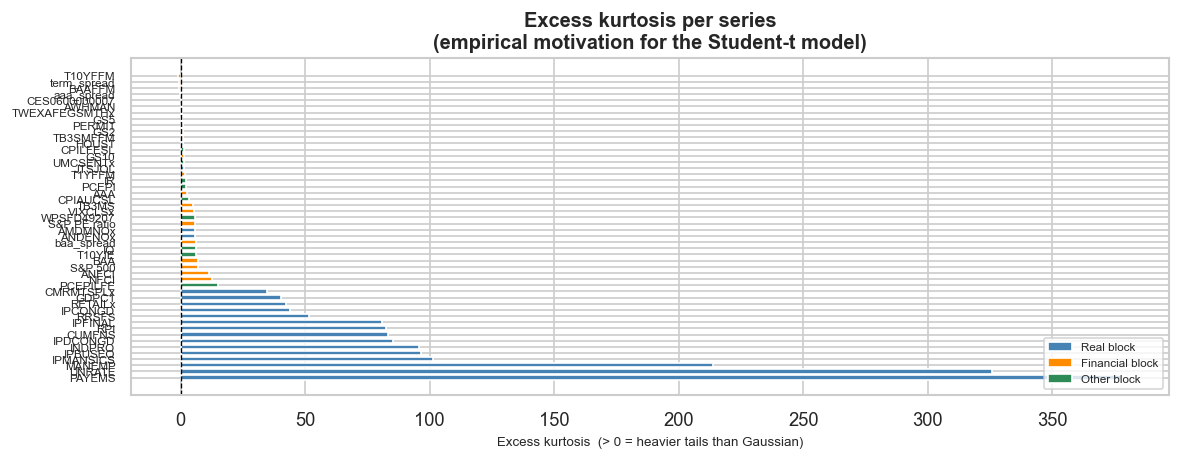


Series with excess kurtosis > 1 (heavy tails): 39 out of 50


In [14]:
# ── excess kurtosis bar chart ─────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 4))

kurt   = stats_df["ex_kurtosis"].sort_values(ascending=False)
colors = [block_colors.get(BLOCK.get(s, "other"), "gray") for s in kurt.index]

ax.barh(kurt.index, kurt.values, color=colors, height=0.7)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Excess kurtosis  (> 0 = heavier tails than Gaussian)", fontsize=8)
ax.set_title(
    "Excess kurtosis per series\n(empirical motivation for the Student-t model)",
    fontweight="bold",
)
ax.tick_params(axis="y", labelsize=7)

legend_elements = [
    Patch(facecolor=c, label=b.capitalize() + " block")
    for b, c in block_colors.items()
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nSeries with excess kurtosis > 1 (heavy tails): "
      f"{(kurt > 1).sum()} out of {len(kurt)}")

### 5. Correlation Structure

**What this cell does:** computes the lower-triangle correlation matrix between the 19 transformed monthly series (GDPC1 excluded because it is quarterly and observed only 4 times per year).

**Why we examine it:** the DFM assumes that all observed co-movement is explained by $r$ common factors $\mathbf{f}_t$. Blocks of high pairwise correlation suggest that $r$ factors with $r \ll M$ can represent the structure efficiently. The variance decomposition is:
$$\text{Cov}(y_t) = \boldsymbol{\Lambda} \boldsymbol{\Lambda}^\top + \mathbf{R}$$
where $\mathbf{R}$ is diagonal (idiosyncratic noise). The variance share captured by the factors should be large for highly correlated pairs.

**What to look for:**
- **Real block** (first 8 rows/columns): strong positive correlations — industrial production, employment, and retail sales co-move over the business cycle.
- **Financial block**: mixed signs — S&P 500 and credit spreads are negatively correlated (risk-on vs. risk-off).
- **Cross-block correlations**: real–financial linkages reflect the financial-cycle transmission channel.

**Thesis reference:** see Section 2.2 (Factor Structure: The DGP of Observations) — in particular the discussion of how many factors $r$ are needed to capture the observed correlation structure, motivating the choice $r = 3$ (one real, one financial, one global factor).\


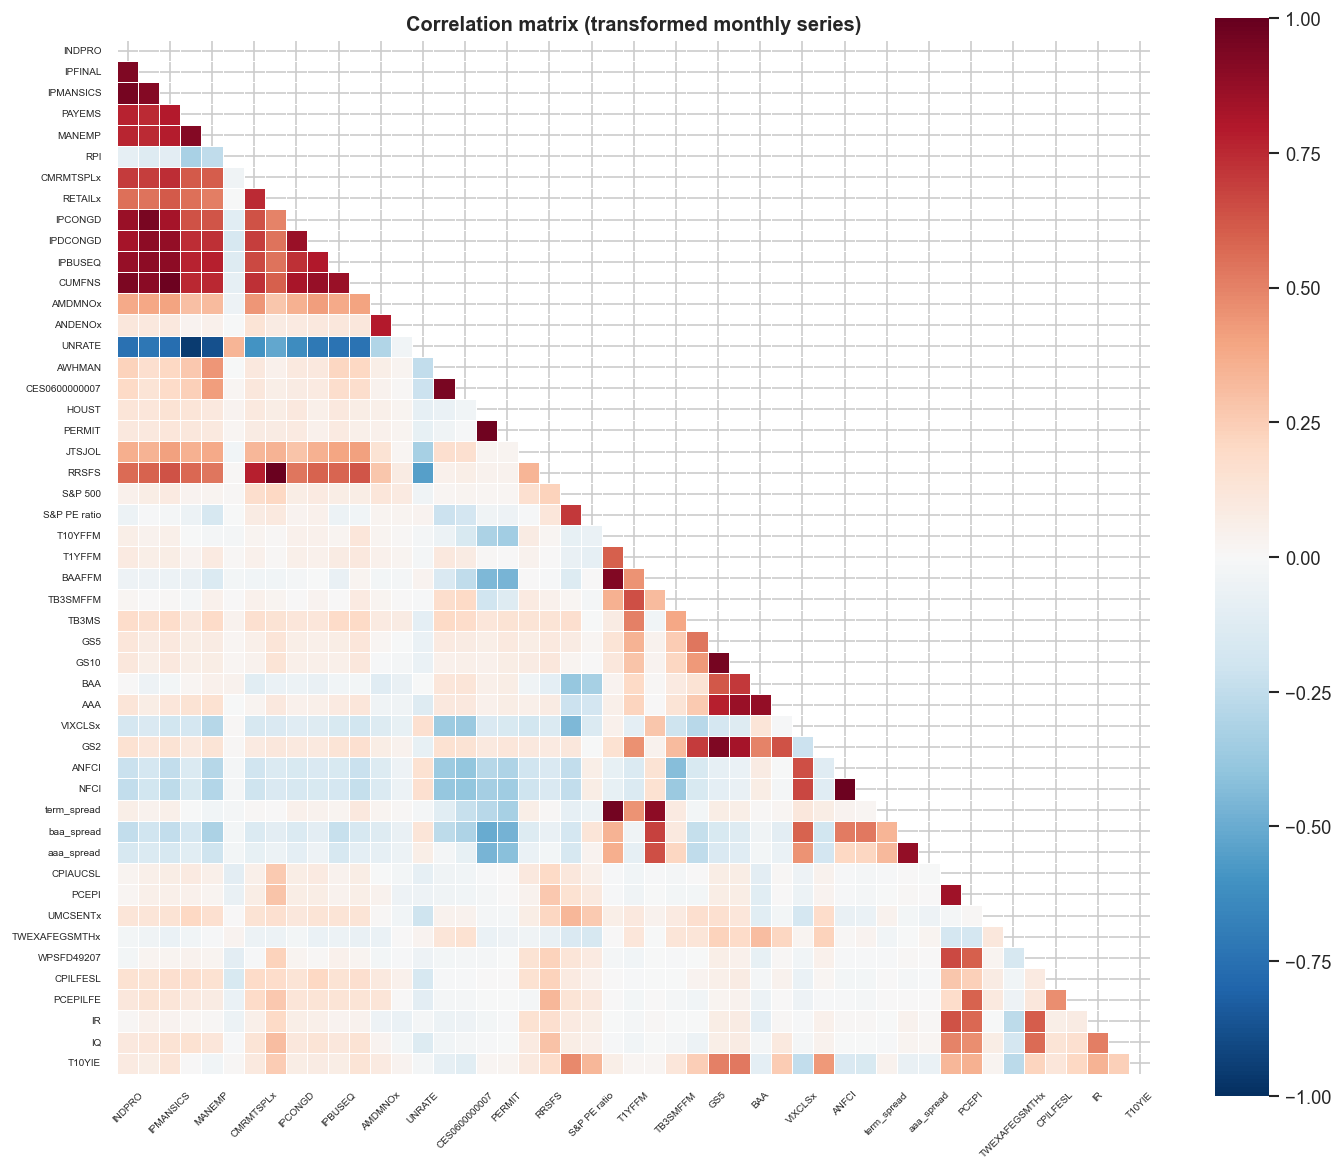

In [15]:
# ── correlation matrix (monthly series only) ──────────────────────────────────
monthly_cols = [c for c in ORDERED_COLS if c != "GDPC1"]
corr = df[monthly_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.3,
    annot=False,
    ax=ax,
)
ax.set_title("Correlation matrix (transformed monthly series)", fontweight="bold")
ax.tick_params(axis="x", labelsize=6, rotation=45)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

### 6. Dataset Structure Validation (Sanity Checks)

**What this cell does:** runs programmatic assertions on the structural properties of the dataset — the minimum prerequisites the dataset must satisfy before the Kalman filter can be implemented.

**Invariants to verify:**
1. Exactly **20 series** (19 monthly + 1 quarterly) — the model is calibrated to this dimension.
2. GDPC1 observed only in quarter-end months (3, 6, 9, 12) — the selection matrix $\mathbf{W}_t$ encodes this structure.
3. The number of GDP observations is approximately $T/3$ — confirms quarterly frequency.

If any assertion fails, the dataset has been modified in an unexpected way and model estimation would produce incorrect results. Re-run `src/data_loader.py` to regenerate the file.

**What to look for:** all three assertions should pass and the cell should print `[PASS] All checks passed`.\


In [16]:
# ── dataset structure validation ─────────────────────────────────────────────
n_real = sum(1 for c in ORDERED_COLS if BLOCK.get(c) == 'real')
n_fin  = sum(1 for c in ORDERED_COLS if BLOCK.get(c) == 'financial')
n_oth  = sum(1 for c in ORDERED_COLS if BLOCK.get(c) == 'other')

print("=== Dataset structure validation ===")
print(f"Config            : {CONFIG}")
print(f"Total series      : {df.shape[1]}  (config expects: {len(ORDERED_COLS)})")
print(f"Real block        : {n_real}")
print(f"Financial block   : {n_fin}")
print(f"Other block       : {n_oth}")
print()

gdp_obs             = df["GDPC1"].notna().sum()
gdp_expected_approx = len(df) // 3
print(f"GDPC1 observations : {gdp_obs}  (approx. {gdp_expected_approx} expected)")

gdp_months = df.index[df["GDPC1"].notna()].month.unique()
print(f"Months where GDPC1 != NaN : {sorted(gdp_months)}  (expected: [3, 6, 9, 12])")

assert set(gdp_months).issubset({3, 6, 9, 12}), \
    "ERROR: GDPC1 present in non-quarter-end months!"
assert df.shape[1] == len(ORDERED_COLS), \
    f"ERROR: expected {len(ORDERED_COLS)} series, found {df.shape[1]}"
assert list(df.columns) == ORDERED_COLS, \
    "ERROR: column order does not match the config ORDERED_COLS!"
print()
print("[PASS] All checks passed.")

=== Dataset structure validation ===
Config            : big
Total series      : 50  (config expects: 50)
Real block        : 22
Financial block   : 18
Other block       : 10

GDPC1 observations : 165  (approx. 166 expected)
Months where GDPC1 != NaN : [3, 6, 9, 12]  (expected: [3, 6, 9, 12])

[PASS] All checks passed.
